# Config A — Tabular Reinforcement Learning

Combined notebook covering Dynamic Programming, Q-Learning, and SARSA on the discrete ICU-Sepsis-v2 environment (716 states, 25 actions). All hyperparameter searches are parallelised with joblib and cached to `results/config_a/` so the notebook can be re-run without retraining.

### Why these algorithms?

Config A's environment is a finite, fully-observed MDP with 716 states and 25 actions (17,900 Q-table entries) — small enough for tabular methods, and the full transition model is accessible. This makes three algorithm families directly comparable:

- **Dynamic Programming (Policy Iteration, Value Iteration)** — model-based: computes the exact optimal policy from P and R without any environment interaction. Serves as the oracle upper bound for what any model-free method can achieve.
- **Q-Learning** — model-free, off-policy: learns Q*(s,a) from experience using the Bellman optimality backup. Off-policy updates allow it to evaluate the greedy policy while behaving ε-greedily, making it more aggressive in exploitation.
- **SARSA** — model-free, on-policy: learns the value of the policy it is currently following, accounting for the cost of its own exploratory actions. More conservative than Q-Learning, which is advantageous when the cost of exploration is high.

Having all three lets us quantify exactly what model-free learning costs: the gap between DP and Q-Learning/SARSA directly measures the price of not knowing P and R.

In [1]:
import sys, os, json, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# run from project root so paths like results/ and plots/ resolve correctly
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir(project_root)

from envs.env_setup import make_sepsis_env, N_STATES, N_ACTIONS, GAMMA
from utils.evaluation import eval_agent, print_results
from agents.config_a.q_learning import QLearningAgent, QLearningConfig
from agents.config_a.sarsa import SARSAAgent, SARSAConfig
from utils.search import run_ql_trial, run_sarsa_trial

SEED = 42
N_EVAL = 1000
N_JOBS = 4

RESULTS_DIR = 'results/config_a'
SEARCH_DIR = 'results/config_a/search'
os.makedirs(SEARCH_DIR, exist_ok=True)

print(f"State space : {N_STATES} states")
print(f"Action space: {N_ACTIONS} actions")
print(f"Gamma       : {GAMMA}")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


State space : 716 states
Action space: 25 actions
Gamma       : 1.0


## 1 Random Baseline

A uniformly random policy provides the lower bound against which all learned policies are measured.

In [2]:
np.random.seed(SEED)
random_policy = lambda obs: int(np.random.randint(N_ACTIONS))
random_results = eval_agent(random_policy, make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
print_results("Random Baseline", random_results)


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline ===
  Mean return  : 0.6395 ± 0.4445
  Survival rate: 74.3%
  Mean ep len  : 10.3


## 2 Dynamic Programming

Dynamic Programming (DP) is a **model-based** method: it computes the optimal policy directly from the known transition matrix P(s'|s,a) and reward matrix R(s,a,s'), without any environment interaction during training. This is feasible in Config A because the full MDP is accessible.

Two algorithms are compared:
- **Policy Iteration** — alternates between full policy evaluation (Bellman expectation) and greedy policy improvement until the policy stabilises.
- **Value Iteration** — combines both steps into a single Bellman optimality sweep, requiring more iterations but simpler implementation.

Both use convergence threshold ε = 1×10⁻⁶ and γ = 1.0 (no temporal discounting, per the ICU-Sepsis paper convention).

In [3]:
# DP functions adapted from the DP teammate notebook

def compute_expected_reward(P, R):
    return np.sum(P * R, axis=2)

def compute_value_function(policy, P, R_expected, gamma=1.0, tol=1e-6, max_iter=10_000):
    n_states = P.shape[0]
    V = np.zeros(n_states)
    for _ in range(max_iter):
        V_new = np.array([
            np.sum(P[s, policy[s]] * (R_expected[s, policy[s]] + gamma * V))
            for s in range(n_states)
        ])
        if np.max(np.abs(V_new - V)) < tol:
            break
        V = V_new
    return V

def extract_policy(V, P, R_expected, gamma=1.0):
    n_states, n_actions = R_expected.shape
    Q = np.array([
        [np.sum(P[s, a] * (R_expected[s, a] + gamma * V)) for a in range(n_actions)]
        for s in range(n_states)
    ])
    return np.argmax(Q, axis=1)

def policy_iteration(P, R, gamma=1.0, tol=1e-6, max_iter=1_000):
    R_exp = compute_expected_reward(P, R)
    n_states = P.shape[0]
    policy = np.zeros(n_states, dtype=int)
    deltas = []
    for i in range(max_iter):
        V = compute_value_function(policy, P, R_exp, gamma, tol)
        new_policy = extract_policy(V, P, R_exp, gamma)
        delta = np.sum(new_policy != policy)
        deltas.append(delta)
        if np.array_equal(new_policy, policy):
            print(f"Policy Iteration converged after {i+1} iteration(s).")
            break
        policy = new_policy
    return policy, V, deltas

def value_iteration(P, R, gamma=1.0, tol=1e-6, max_iter=10_000):
    R_exp = compute_expected_reward(P, R)
    n_states, n_actions = R_exp.shape
    V = np.zeros(n_states)
    deltas = []
    for i in range(max_iter):
        Q = np.array([
            [np.sum(P[s, a] * (R_exp[s, a] + gamma * V)) for a in range(n_actions)]
            for s in range(n_states)
        ])
        V_new = np.max(Q, axis=1)
        delta = np.max(np.abs(V_new - V))
        deltas.append(delta)
        V = V_new
        if delta < tol:
            print(f"Value Iteration converged after {i+1} iteration(s).")
            break
    policy = np.argmax(Q, axis=1)
    return policy, V, deltas

def get_dp_policy(policy_array):
    return lambda obs: int(policy_array[obs])

# extract MDP matrices from the environment
_env = make_sepsis_env(verbose=False)
_raw = _env.unwrapped
P = _raw._tx_mat  # (S, A, S)
R = _raw._r_mat   # (S, A, S)
print(f"P shape: {P.shape},  R shape: {R.shape}")


P shape: (716, 25, 716),  R shape: (716, 25, 716)


### 2.1 Gamma Sensitivity

In [4]:
# Grid search over gamma — cached to CSV
DP_GAMMA_CSV = f'{RESULTS_DIR}/dp_gamma_results.csv'

if os.path.exists(DP_GAMMA_CSV):
    dp_gamma_df = pd.read_csv(DP_GAMMA_CSV)
    print("Loaded DP gamma results from cache.")
else:
    gamma_grid = [0.90, 0.95, 0.99, 1.00]
    rows = []
    for g in gamma_grid:
        pi_pol, _, _ = policy_iteration(P, R, gamma=g)
        vi_pol, _, _ = value_iteration(P, R, gamma=g)
        pi_res = eval_agent(get_dp_policy(pi_pol), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
        vi_res = eval_agent(get_dp_policy(vi_pol), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
        rows.append({'gamma': g, 'pi_survival': pi_res['survival_rate'],
                     'vi_survival': vi_res['survival_rate'],
                     'pi_return': pi_res['mean_return'], 'vi_return': vi_res['mean_return']})
    dp_gamma_df = pd.DataFrame(rows)
    dp_gamma_df.to_csv(DP_GAMMA_CSV, index=False)
    print("DP gamma grid complete.")

print(dp_gamma_df.to_string(index=False))


Loaded DP gamma results from cache.
 gamma  pi_survival  vi_survival  pi_return  vi_return
  0.90        0.767        0.767   0.743590   0.743590
  0.95        0.800        0.800   0.773400   0.773400
  0.99        0.830        0.830   0.795682   0.795682
  1.00        0.832        0.832   0.791400   0.791400


### 2.2 Final Run (γ = 1.0) and Convergence

In [5]:
pi_policy, pi_V, pi_deltas = policy_iteration(P, R, gamma=1.0)
vi_policy, vi_V, vi_deltas = value_iteration(P, R, gamma=1.0)

pi_results = eval_agent(get_dp_policy(pi_policy), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
vi_results = eval_agent(get_dp_policy(vi_policy), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)

print_results("Policy Iteration (gamma=1.0)", pi_results)
print_results("Value Iteration  (gamma=1.0)", vi_results)

# save for the comparison table in section 5
np.savez(f'{RESULTS_DIR}/dp_results.npz',
         pi_survival=np.array([pi_results['survival_rate']]),
         vi_survival=np.array([vi_results['survival_rate']]),
         pi_return=np.array([pi_results['mean_return']]),
         vi_return=np.array([vi_results['mean_return']]))


Policy Iteration converged after 4 iteration(s).
Value Iteration converged after 135 iteration(s).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Policy Iteration (gamma=1.0) ===
  Mean return  : 0.7914 ± 0.3710
  Survival rate: 83.2%
  Mean ep len  : 10.6
=== Value Iteration  (gamma=1.0) ===
  Mean return  : 0.7914 ± 0.3710
  Survival rate: 83.2%
  Mean ep len  : 10.6


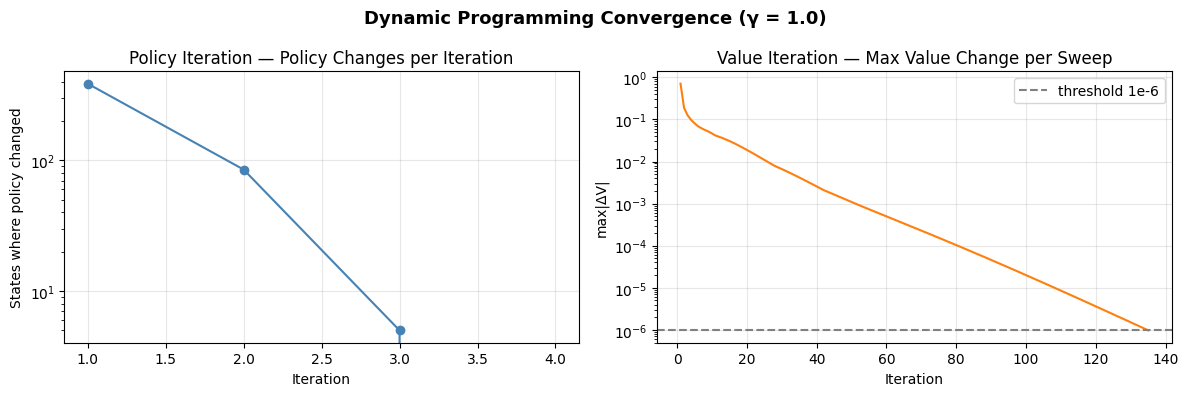

In [6]:
# Convergence curves — Policy Iteration vs Value Iteration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(pi_deltas)+1), pi_deltas, marker='o', color='steelblue')
axes[0].set_title('Policy Iteration — Policy Changes per Iteration')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('States where policy changed')
axes[0].set_yscale('log'); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(vi_deltas)+1), vi_deltas, color='tab:orange')
axes[1].set_title('Value Iteration — Max Value Change per Sweep')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('max|ΔV|')
axes[1].set_yscale('log'); axes[1].axhline(1e-6, linestyle='--', color='grey', label='threshold 1e-6')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Dynamic Programming Convergence (γ = 1.0)', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/configA_dp_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 Q-Learning

Q-Learning is an **off-policy**, **model-free** tabular TD method. It learns the optimal action-value function Q*(s,a) via the update:

> Q(s,a) ← Q(s,a) + α [r + γ max_a' Q(s',a') − Q(s,a)]

The max operator makes it off-policy: the update target uses the greedy action in s', regardless of what the behaviour policy actually chose. Training uses ε-greedy exploration with linear decay.

Key difference from DP: Q-Learning requires no knowledge of P or R — it learns entirely from environment interaction.

### 3.1 Hyperparameter Search (Grid)

In [7]:
QL_CSV = f'{SEARCH_DIR}/ql_grid_results.csv'
QL_N_EPS = 10_000
QL_EVAL = 500

ql_grid = {
    'alpha':         [0.05, 0.1, 0.2],
    'epsilon_decay': [5_000, 10_000, 25_000],
    'epsilon_end':   [0.01, 0.05, 0.10],
}
# gamma=1.0 and epsilon_start=1.0 are fixed across all trials
ql_combos = [
    {'alpha': a, 'epsilon_decay': ed, 'epsilon_end': ee,
     'gamma': 1.0, 'epsilon_start': 1.0}
    for a, ed, ee in itertools.product(
        ql_grid['alpha'], ql_grid['epsilon_decay'], ql_grid['epsilon_end']
    )
]
print(f"Q-Learning grid: {len(ql_combos)} combinations  ({N_JOBS} parallel workers)")

if os.path.exists(QL_CSV):
    ql_grid_df = pd.read_csv(QL_CSV)
    print(f"Loaded from cache ({len(ql_grid_df)} trials).")
else:
    ql_results_raw = Parallel(n_jobs=N_JOBS, backend='loky', verbose=5)(
        delayed(run_ql_trial)(i, p, SEARCH_DIR, QL_N_EPS, QL_EVAL, SEED, project_root)
        for i, p in enumerate(ql_combos)
    )
    ql_results_raw = [r for r in ql_results_raw if r is not None]
    ql_grid_df = pd.DataFrame(ql_results_raw).sort_values('survival_rate', ascending=False)
    ql_grid_df.to_csv(QL_CSV, index=False)
    print("Q-Learning grid search complete.")

print("\nTop 5 Q-Learning configurations:")
print(ql_grid_df.head(5).to_string(index=False))


Q-Learning grid: 27 combinations  (4 parallel workers)
Loaded from cache (27 trials).

Top 5 Q-Learning configurations:
 trial  alpha  epsilon_decay  epsilon_end  gamma  epsilon_start  survival_rate  mean_return
    15    0.1          25000         0.01    1.0            1.0          0.772     0.680070
    18    0.2           5000         0.01    1.0            1.0          0.772     0.718705
    12    0.1          10000         0.01    1.0            1.0          0.770     0.709540
    23    0.2          10000         0.10    1.0            1.0          0.768     0.693170
    11    0.1           5000         0.10    1.0            1.0          0.768     0.716030


In [8]:
# Extract best params and save
ql_param_keys = ['alpha', 'epsilon_decay', 'epsilon_end', 'gamma', 'epsilon_start']
best_ql_params = ql_grid_df.iloc[0][ql_param_keys].to_dict()
best_ql_params['alpha'] = float(best_ql_params['alpha'])
best_ql_params['epsilon_decay'] = int(best_ql_params['epsilon_decay'])
best_ql_params['epsilon_end'] = float(best_ql_params['epsilon_end'])

print(f"Best Q-Learning config (survival={ql_grid_df.iloc[0]['survival_rate']:.1%}):")
for k, v in best_ql_params.items():
    print(f"  {k:<20} = {v}")


Best Q-Learning config (survival=77.2%):
  alpha                = 0.1
  epsilon_decay        = 25000
  epsilon_end          = 0.01
  gamma                = 1.0
  epsilon_start        = 1.0


### 3.2 Train Best Configuration

In [9]:
QL_QTABLE  = f'{RESULTS_DIR}/qlearning_qtable.npy'
QL_RETURNS = f'{RESULTS_DIR}/qlearning_returns.npy'
QL_CFG     = f'{RESULTS_DIR}/qlearning_best_config.json'
QL_TRAIN_N = 30_000

# scale epsilon_decay to the longer training run: grid used 10k episodes,
# here we use 30k, so we stretch the decay by the same factor (25k -> 150k steps)
ql_train_params = dict(best_ql_params)
ql_train_params['epsilon_decay'] = 150_000

if os.path.exists(QL_QTABLE) and os.path.exists(QL_RETURNS):
    print("Loading cached Q-Learning model...")
    ql_cfg = QLearningConfig(n_episodes=QL_TRAIN_N, **ql_train_params)
    ql_agent = QLearningAgent(N_STATES, N_ACTIONS, ql_cfg)
    ql_agent.Q = np.load(QL_QTABLE)
    ql_returns = list(np.load(QL_RETURNS))
    with open(QL_CFG) as f:
        print("Config:", json.load(f))
else:
    print(f"Training Q-Learning for {QL_TRAIN_N:,} episodes...")
    ql_cfg = QLearningConfig(n_episodes=QL_TRAIN_N, **ql_train_params)
    ql_agent = QLearningAgent(N_STATES, N_ACTIONS, ql_cfg)
    env = make_sepsis_env(verbose=False)
    ql_returns = []
    for ep in range(QL_TRAIN_N):
        obs, _ = env.reset()
        done = False
        total = 0.0
        while not done:
            a = ql_agent.select_action(obs, training=True)
            next_obs, r, term, trunc, _ = env.step(a)
            done = term or trunc
            ql_agent.update(obs, a, r, next_obs, done)
            obs = next_obs
            total += r
        ql_returns.append(total)
        if (ep + 1) % 5000 == 0:
            surv = np.mean([r > 0 for r in ql_returns[-500:]])
            print(f"  ep {ep+1:,} / {QL_TRAIN_N:,}  |  last-500 survival: {surv:.1%}")
    np.save(QL_QTABLE, ql_agent.Q)
    np.save(QL_RETURNS, np.array(ql_returns))
    with open(QL_CFG, 'w') as f:
        json.dump(ql_train_params, f)
    print("Done, model cached.")

ql_results = eval_agent(ql_agent.get_policy(), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
print_results("Q-Learning (best config)", ql_results)


Loading cached Q-Learning model...
Config: {'alpha': 0.1, 'epsilon_decay': 150000, 'epsilon_end': 0.01, 'gamma': 1.0, 'epsilon_start': 1.0}
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Q-Learning (best config) ===
  Mean return  : 0.6536 ± 0.4376
  Survival rate: 74.4%
  Mean ep len  : 10.1


### 3.3 Training Curve

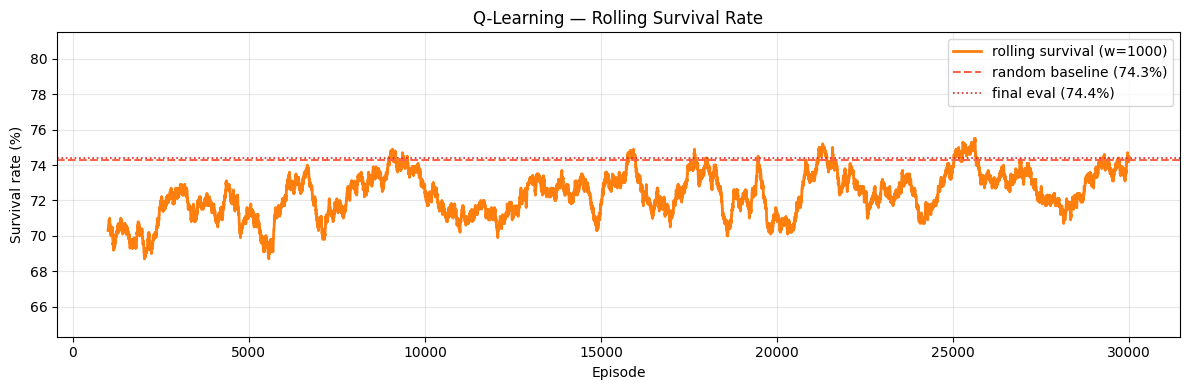

Q-table coverage: 99.6% of states visited


In [10]:
W = 1000  # wider window to smooth out the high variance
ql_surv = np.array([r > 0 for r in ql_returns], dtype=float)
ql_roll = np.convolve(ql_surv, np.ones(W)/W, mode='valid') * 100
x_ql = np.arange(W-1, len(ql_returns))

random_surv = random_results['survival_rate'] * 100
ymin = max(0, random_surv - 10)
ymax = min(100, ql_roll.max() + 6)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_ql, ql_roll, color='tab:orange', linewidth=2,
        label=f'rolling survival (w={W})')
ax.axhline(random_surv, linestyle='--', color='tomato',
           linewidth=1.5, label=f'random baseline ({random_surv:.1f}%)')
ax.axhline(ql_results['survival_rate']*100, linestyle=':', color='tab:red',
           linewidth=1.2, label=f'final eval ({ql_results["survival_rate"]*100:.1f}%)')
ax.set_xlabel('Episode')
ax.set_ylabel('Survival rate (%)')
ax.set_title('Q-Learning — Rolling Survival Rate')
ax.set_ylim(ymin, ymax)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/configA_qlearning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Q-table coverage: {(ql_agent.Q != 0).any(axis=1).mean():.1%} of states visited")


### 3.4 Exploration Schedule

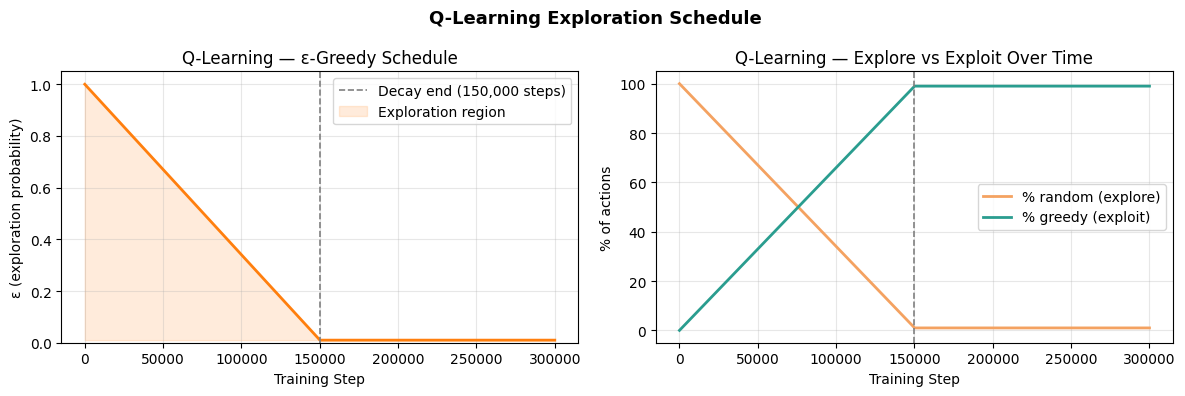

In [11]:
ql_total_steps = QL_TRAIN_N * 10  # rough estimate, ~10 env steps per episode
ql_steps = np.arange(ql_total_steps)

eps_start = float(ql_train_params['epsilon_start'])
eps_end   = float(ql_train_params['epsilon_end'])
eps_decay = int(ql_train_params['epsilon_decay'])
frac = np.minimum(ql_steps / eps_decay, 1.0)
ql_eps_curve = eps_start + frac * (eps_end - eps_start)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(ql_steps, ql_eps_curve, color='tab:orange', linewidth=2)
ax.axvline(eps_decay, color='gray', linestyle='--', linewidth=1.2,
           label=f'Decay end ({eps_decay:,} steps)')
ax.fill_between(ql_steps, ql_eps_curve, eps_end,
                alpha=0.15, color='tab:orange', label='Exploration region')
ax.set_xlabel('Training Step')
ax.set_ylabel('ε (exploration probability)')
ax.set_title('Q-Learning — ε-Greedy Schedule')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ql_steps, ql_eps_curve * 100,       color='#f4a261', linewidth=2, label='% random (explore)')
ax.plot(ql_steps, (1 - ql_eps_curve) * 100, color='#2a9d8f', linewidth=2, label='% greedy (exploit)')
ax.axvline(eps_decay, color='gray', linestyle='--', linewidth=1.2)
ax.set_xlabel('Training Step')
ax.set_ylabel('% of actions')
ax.set_title('Q-Learning — Explore vs Exploit Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Q-Learning Exploration Schedule', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/configA_qlearning_exploration.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 SARSA

SARSA is an **on-policy**, **model-free** tabular TD method. Its update rule is:

> Q(s,a) ← Q(s,a) + α [r + γ Q(s',a') − Q(s,a)]

Unlike Q-Learning, SARSA bootstraps from the *actual next action a'* chosen by the behaviour policy (not the greedy max). This makes it on-policy and generally more conservative: it learns the value of the policy it is currently following, including its exploration. SARSA is better suited to environments where the cost of exploration is high, as it accounts for the risk of exploratory actions during updates.

Additional features implemented:
- **Linear alpha decay**: α decays from `alpha` to `alpha_floor` over `alpha_decay_steps` steps, reducing learning rate as Q-values converge.
- **Optimistic Q initialisation**: `q_init=1.0` initialises all Q-values to 1, encouraging early exploration of all state-action pairs.
- **Hyperparameter search**: Optuna TPE sampler over 7 dimensions.

### 4.1 Hyperparameter Search (Optuna)

In [12]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SARSA_BEST_JSON = f'{RESULTS_DIR}/sarsa_best_params.json'
SARSA_N_EPS = 5_000
SARSA_N_TRIALS = 200

if os.path.exists(SARSA_BEST_JSON):
    with open(SARSA_BEST_JSON) as f:
        sarsa_search_result = json.load(f)
    best_sarsa_params = sarsa_search_result['params']
    print(f"Loaded from cache (best survival={sarsa_search_result['best_survival']:.1%}).")
    print("Best params:", best_sarsa_params)
else:
    print(f"Running Optuna search ({SARSA_N_TRIALS} trials, {SARSA_N_EPS} eps each)...")

    def _sarsa_objective(trial):
        params = {
            'alpha': trial.suggest_categorical('alpha', [0.2, 0.1, 0.05]),
            # gamma kept >= 0.9 — lower values make the agent clinically myopic
            'gamma': trial.suggest_categorical('gamma', [1.0, 0.99, 0.95, 0.9]),
            'epsilon_start': trial.suggest_categorical('epsilon_start', [0.9, 0.7, 0.5, 0.3]),
            'epsilon_end': trial.suggest_categorical('epsilon_end', [0.01, 0.1, 0.2, 0.3]),
            'epsilon_decay': trial.suggest_categorical('epsilon_decay', [3000, 2000, 1000, 500]),
            'alpha_decay': trial.suggest_categorical('alpha_decay', ['constant', 'linear']),
            'q_init': trial.suggest_categorical('q_init', [0.0, 1.0, 'random']),
        }
        cfg = SARSAConfig(n_episodes=SARSA_N_EPS, **params)
        agent = SARSAAgent(N_STATES, N_ACTIONS, cfg)
        returns = agent.train(make_sepsis_env)
        return float(np.mean([r > 0 for r in returns[-500:]]))

    sarsa_study = optuna.create_study(direction='maximize',
                                      sampler=optuna.samplers.TPESampler(seed=SEED))
    sarsa_study.optimize(_sarsa_objective, n_trials=SARSA_N_TRIALS, show_progress_bar=True)

    best_sarsa_params = sarsa_study.best_params
    best_sarsa_survival = sarsa_study.best_value
    sarsa_search_result = {'params': best_sarsa_params, 'best_survival': best_sarsa_survival}
    with open(SARSA_BEST_JSON, 'w') as f:
        json.dump(sarsa_search_result, f)
    print(f"Best survival (in-trial): {best_sarsa_survival:.1%}")
    print("Best params:", best_sarsa_params)


Loaded from cache (best survival=76.4%).
Best params: {'alpha': 0.2, 'gamma': 0.99, 'epsilon_start': 0.9, 'epsilon_end': 0.1, 'epsilon_decay': 500, 'alpha_decay': 'linear', 'q_init': 'random'}


In [13]:
# Optuna visualisations (only rendered when search was run this session)
try:
    fig1 = optuna.visualization.plot_optimization_history(sarsa_study)
    fig1.show()
    fig2 = optuna.visualization.plot_param_importances(sarsa_study)
    fig2.show()
except NameError:
    print("Re-run the Hyperparameter Search cell (4.1) to generate Optuna visualisations.")


Re-run the Hyperparameter Search cell (4.1) to generate Optuna visualisations.


### 4.2 Train Best Configuration

In [14]:
SARSA_QTABLE  = f'{RESULTS_DIR}/sarsa_qtable.npy'
SARSA_RETURNS = f'{RESULTS_DIR}/sarsa_returns.npy'
SARSA_TRAIN_N = 30_000

if os.path.exists(SARSA_QTABLE) and os.path.exists(SARSA_RETURNS):
    print("Loading cached SARSA model...")
    sarsa_cfg = SARSAConfig(n_episodes=SARSA_TRAIN_N, **best_sarsa_params)
    sarsa_agent = SARSAAgent(N_STATES, N_ACTIONS, sarsa_cfg)
    sarsa_agent.Q = np.load(SARSA_QTABLE)
    sarsa_returns = list(np.load(SARSA_RETURNS))
else:
    print(f"Training SARSA ({SARSA_TRAIN_N:,} episodes) with best config...")
    sarsa_cfg = SARSAConfig(n_episodes=SARSA_TRAIN_N, **best_sarsa_params)
    sarsa_agent = SARSAAgent(N_STATES, N_ACTIONS, sarsa_cfg)
    sarsa_returns = sarsa_agent.train(make_sepsis_env)
    np.save(SARSA_QTABLE, sarsa_agent.Q)
    np.save(SARSA_RETURNS, np.array(sarsa_returns))
    print("SARSA model cached.")

sarsa_results = eval_agent(sarsa_agent.get_policy(), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
print_results("SARSA (best config)", sarsa_results)


Loading cached SARSA model...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== SARSA (best config) ===
  Mean return  : 0.6578 ± 0.4303
  Survival rate: 75.2%
  Mean ep len  : 10.5


### 4.3 Training Curve and Exploration Schedule

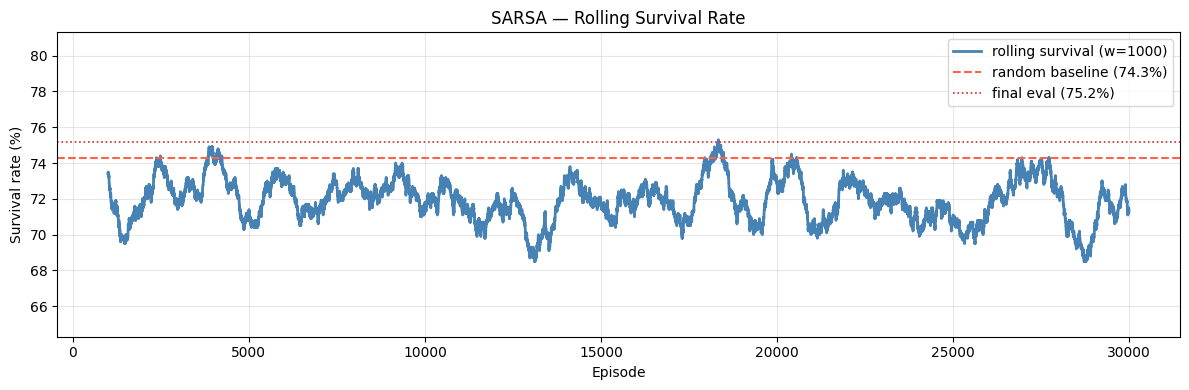

In [15]:
W = 1000
sarsa_surv = np.array([r > 0 for r in sarsa_returns], dtype=float)
sarsa_roll = np.convolve(sarsa_surv, np.ones(W)/W, mode='valid') * 100
x_sarsa = np.arange(W-1, len(sarsa_returns))

random_surv = random_results['survival_rate'] * 100
ymin = max(0, random_surv - 10)
ymax = min(100, sarsa_roll.max() + 6)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_sarsa, sarsa_roll, color='steelblue', linewidth=2,
        label=f'rolling survival (w={W})')
ax.axhline(random_surv, linestyle='--', color='tomato',
           linewidth=1.5, label=f'random baseline ({random_surv:.1f}%)')
ax.axhline(sarsa_results['survival_rate']*100, linestyle=':', color='tab:red',
           linewidth=1.2, label=f'final eval ({sarsa_results["survival_rate"]*100:.1f}%)')
ax.set_xlabel('Episode')
ax.set_ylabel('Survival rate (%)')
ax.set_title('SARSA — Rolling Survival Rate')
ax.set_ylim(ymin, ymax)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/configA_sarsa_curve.png', dpi=150, bbox_inches='tight')
plt.show()


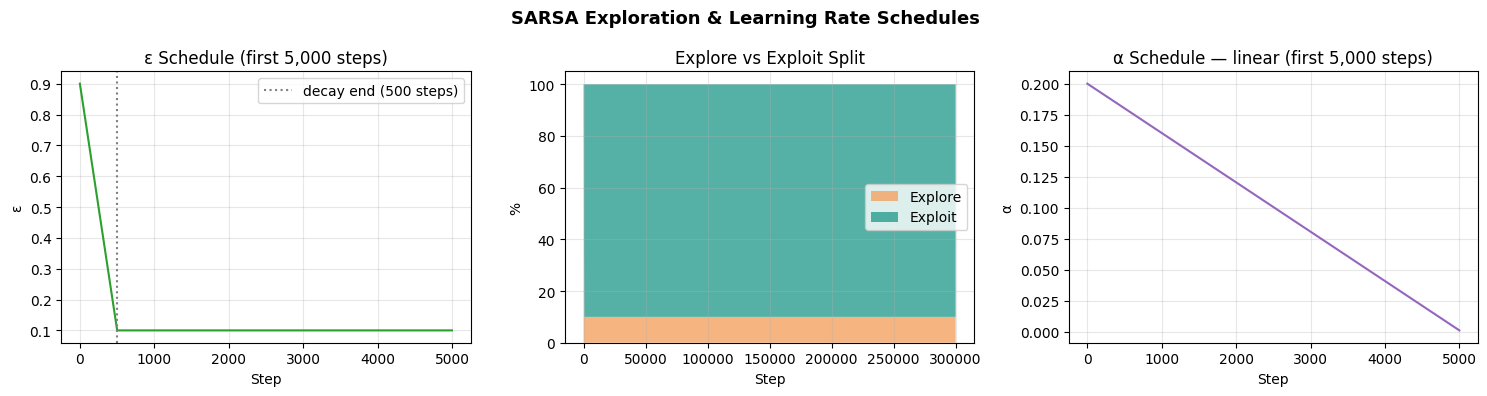

In [16]:
total_steps = SARSA_TRAIN_N * 10
steps = np.arange(total_steps)

eps_start = float(best_sarsa_params['epsilon_start'])
eps_end   = float(best_sarsa_params['epsilon_end'])
eps_decay = int(best_sarsa_params['epsilon_decay'])
frac_eps = np.minimum(steps / eps_decay, 1.0)
epsilon_curve = eps_start + frac_eps * (eps_end - eps_start)

alpha_val = float(best_sarsa_params['alpha'])
alpha_decay = best_sarsa_params['alpha_decay']
alpha_floor = sarsa_cfg.alpha_floor
alpha_steps = sarsa_cfg.alpha_decay_steps
if alpha_decay == 'linear':
    frac_a = np.minimum(steps / alpha_steps, 1.0)
    alpha_curve = alpha_val + frac_a * (alpha_floor - alpha_val)
else:
    alpha_curve = np.full(len(steps), alpha_val)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# zoom x-axis to 10x the decay length so the drop is actually visible
zoom = min(eps_decay * 10, total_steps)
axes[0].plot(steps[:zoom], epsilon_curve[:zoom], color='tab:green', linewidth=1.5)
axes[0].axvline(eps_decay, linestyle=':', color='grey', label=f'decay end ({eps_decay} steps)')
axes[0].set_title(f'ε Schedule (first {zoom:,} steps)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('ε')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Explore vs Exploit — full training view
exploit = (1 - epsilon_curve) * 100
explore = epsilon_curve * 100
axes[1].stackplot(steps, explore, exploit, labels=['Explore', 'Exploit'],
                  colors=['#f4a261', '#2a9d8f'], alpha=0.8)
axes[1].set_title('Explore vs Exploit Split')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('%')
axes[1].legend(loc='right')
axes[1].grid(True, alpha=0.3)

# Learning rate — zoom same as epsilon
axes[2].plot(steps[:zoom], alpha_curve[:zoom], color='tab:purple', linewidth=1.5)
axes[2].set_title(f'α Schedule — {alpha_decay} (first {zoom:,} steps)')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('α')
axes[2].grid(True, alpha=0.3)

plt.suptitle('SARSA Exploration & Learning Rate Schedules', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/configA_sarsa_schedules.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 Comparative Analysis

All algorithms evaluated with the same fixed protocol: `eval_agent(..., n_eval_episodes=1000, seed=42)`. Q-Learning and SARSA are both trained for **30,000 episodes** for a fair head-to-head comparison. DP computes the optimal policy analytically — no episode budget is needed.

### 5.1 Training Curves

DP is model-based and produces no training curve — it computes the optimal policy in a single pass from the MDP matrices. For Q-Learning and SARSA, both trained for 30,000 episodes, the curves show how the rolling survival rate evolves during learning.

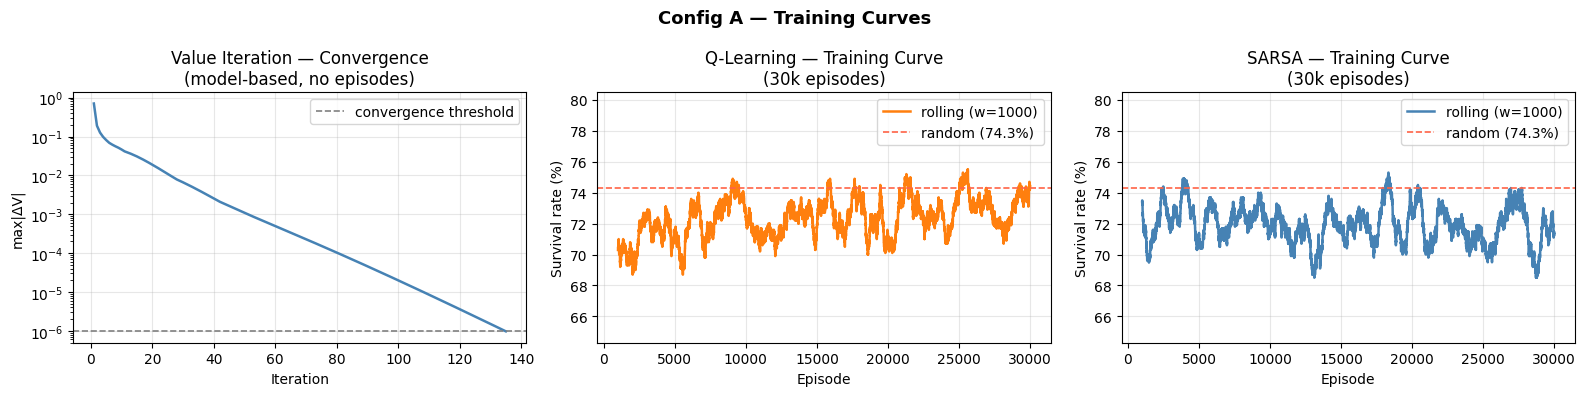

In [17]:
W = 1000
random_surv = random_results['survival_rate'] * 100

# compute rolls first so we can set shared y limits
ql_surv_c = np.array([r > 0 for r in ql_returns], dtype=float)
ql_roll_c = np.convolve(ql_surv_c, np.ones(W)/W, mode='valid') * 100

sarsa_surv_c = np.array([r > 0 for r in sarsa_returns], dtype=float)
sarsa_roll_c = np.convolve(sarsa_surv_c, np.ones(W)/W, mode='valid') * 100

y_lo = max(0, random_surv - 10)
y_hi = min(100, max(ql_roll_c.max(), sarsa_roll_c.max()) + 5)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# DP convergence
ax = axes[0]
ax.plot(range(1, len(vi_deltas)+1), vi_deltas, color='steelblue', linewidth=1.8)
ax.axhline(1e-6, linestyle='--', color='grey', linewidth=1.2, label='convergence threshold')
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('max|ΔV|')
ax.set_title('Value Iteration — Convergence\n(model-based, no episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Q-Learning
ax = axes[1]
x_ql_c = np.arange(W-1, len(ql_returns))
ax.plot(x_ql_c, ql_roll_c, color='tab:orange', linewidth=1.8, label=f'rolling (w={W})')
ax.axhline(random_surv, linestyle='--', color='tomato', linewidth=1.2,
           label=f'random ({random_surv:.1f}%)')
ax.set_xlabel('Episode')
ax.set_ylabel('Survival rate (%)')
ax.set_title('Q-Learning — Training Curve\n(30k episodes)')
ax.set_ylim(y_lo, y_hi)
ax.legend()
ax.grid(True, alpha=0.3)

# SARSA
ax = axes[2]
x_sarsa_c = np.arange(W-1, len(sarsa_returns))
ax.plot(x_sarsa_c, sarsa_roll_c, color='steelblue', linewidth=1.8, label=f'rolling (w={W})')
ax.axhline(random_surv, linestyle='--', color='tomato', linewidth=1.2,
           label=f'random ({random_surv:.1f}%)')
ax.set_xlabel('Episode')
ax.set_ylabel('Survival rate (%)')
ax.set_title('SARSA — Training Curve\n(30k episodes)')
ax.set_ylim(y_lo, y_hi)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Config A — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/configA_all_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Exploration vs Exploitation

DP is fully deterministic — it uses no exploration. Q-Learning and SARSA both use ε-greedy policies during training. The chart below shows how the balance between random exploration and greedy exploitation shifts over the course of training for each method.

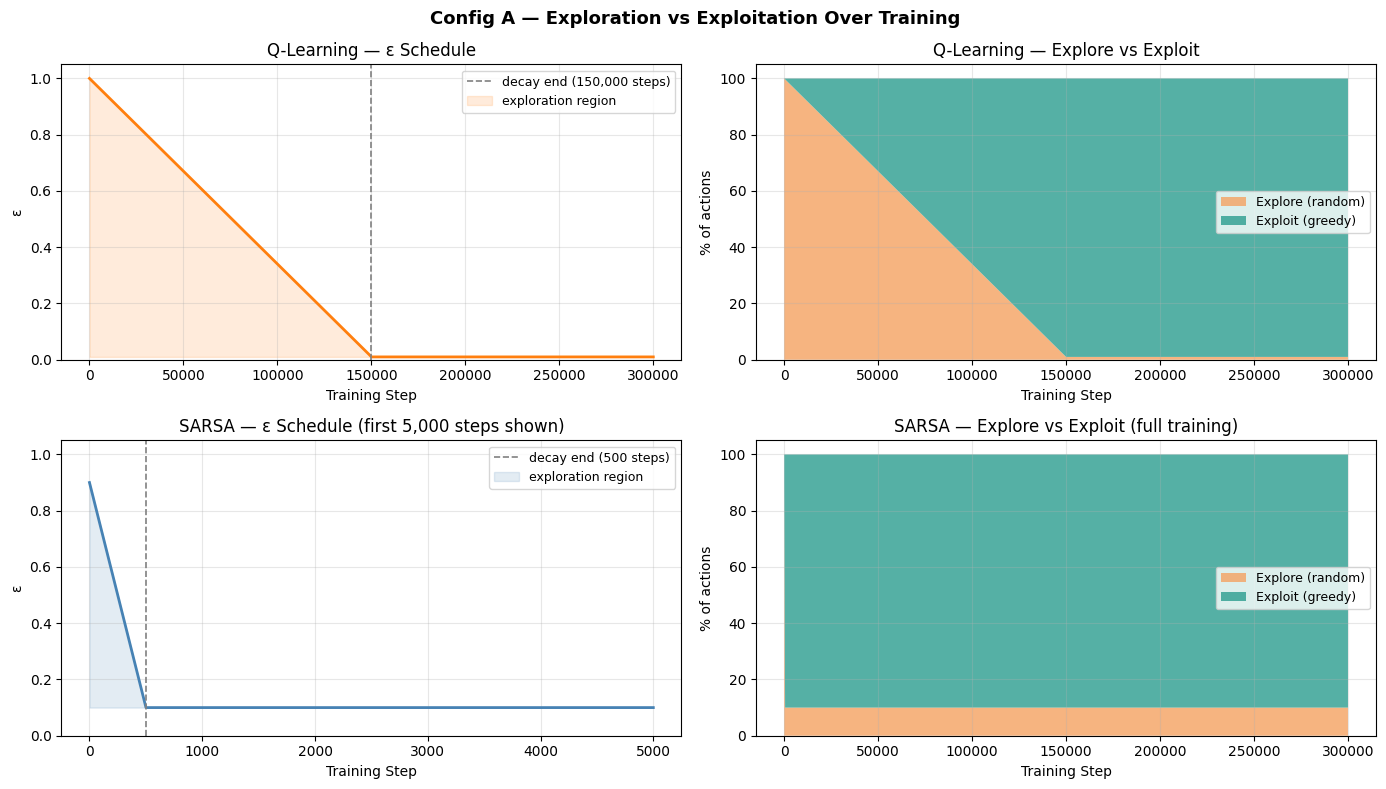

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Q-Learning row
ql_steps_c = np.arange(QL_TRAIN_N * 10)
eps_start_ql = float(ql_train_params['epsilon_start'])
eps_end_ql   = float(ql_train_params['epsilon_end'])
eps_decay_ql = int(ql_train_params['epsilon_decay'])
frac_ql = np.minimum(ql_steps_c / eps_decay_ql, 1.0)
eps_ql  = eps_start_ql + frac_ql * (eps_end_ql - eps_start_ql)

ax = axes[0, 0]
ax.plot(ql_steps_c, eps_ql, color='tab:orange', linewidth=2)
ax.axvline(eps_decay_ql, color='gray', linestyle='--', linewidth=1.2,
           label=f'decay end ({eps_decay_ql:,} steps)')
ax.fill_between(ql_steps_c, eps_ql, eps_end_ql, alpha=0.15, color='tab:orange',
                label='exploration region')
ax.set_xlabel('Training Step')
ax.set_ylabel('ε')
ax.set_title('Q-Learning — ε Schedule')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.stackplot(ql_steps_c, eps_ql * 100, (1 - eps_ql) * 100,
             labels=['Explore (random)', 'Exploit (greedy)'],
             colors=['#f4a261', '#2a9d8f'], alpha=0.8)
ax.set_xlabel('Training Step')
ax.set_ylabel('% of actions')
ax.set_title('Q-Learning — Explore vs Exploit')
ax.legend(loc='right', fontsize=9)
ax.grid(True, alpha=0.3)

# SARSA row — zoom x-axis so the fast decay is visible
sarsa_steps_c = np.arange(SARSA_TRAIN_N * 10)
eps_start_sa = float(best_sarsa_params['epsilon_start'])
eps_end_sa   = float(best_sarsa_params['epsilon_end'])
eps_decay_sa = int(best_sarsa_params['epsilon_decay'])
frac_sa = np.minimum(sarsa_steps_c / eps_decay_sa, 1.0)
eps_sa  = eps_start_sa + frac_sa * (eps_end_sa - eps_start_sa)
zoom_sa = eps_decay_sa * 10  # show 10x the decay window

ax = axes[1, 0]
ax.plot(sarsa_steps_c[:zoom_sa], eps_sa[:zoom_sa], color='steelblue', linewidth=2)
ax.axvline(eps_decay_sa, color='gray', linestyle='--', linewidth=1.2,
           label=f'decay end ({eps_decay_sa} steps)')
ax.fill_between(sarsa_steps_c[:zoom_sa], eps_sa[:zoom_sa], eps_end_sa,
                alpha=0.15, color='steelblue', label='exploration region')
ax.set_xlabel('Training Step')
ax.set_ylabel('ε')
ax.set_title(f'SARSA — ε Schedule (first {zoom_sa:,} steps shown)')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.stackplot(sarsa_steps_c, eps_sa * 100, (1 - eps_sa) * 100,
             labels=['Explore (random)', 'Exploit (greedy)'],
             colors=['#f4a261', '#2a9d8f'], alpha=0.8)
ax.set_xlabel('Training Step')
ax.set_ylabel('% of actions')
ax.set_title('SARSA — Explore vs Exploit (full training)')
ax.legend(loc='right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Config A — Exploration vs Exploitation Over Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/configA_exploration_combined.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Results Table

In [19]:
# Load DP results from cache
_dp = np.load(f'{RESULTS_DIR}/dp_results.npz')
pi_surv = float(_dp['pi_survival'][0])
vi_surv = float(_dp['vi_survival'][0])
pi_ret  = float(_dp['pi_return'][0])
vi_ret  = float(_dp['vi_return'][0])

results_table = pd.DataFrame([
    {'Algorithm': 'Random Baseline',  'Type': 'Baseline',
     'Episodes': '—',
     'Survival Rate': random_results['survival_rate'],
     'Mean Return':   random_results['mean_return']},
    {'Algorithm': 'Policy Iteration', 'Type': 'Model-based (DP)',
     'Episodes': '—',
     'Survival Rate': pi_surv, 'Mean Return': pi_ret},
    {'Algorithm': 'Value Iteration',  'Type': 'Model-based (DP)',
     'Episodes': '—',
     'Survival Rate': vi_surv, 'Mean Return': vi_ret},
    {'Algorithm': 'Q-Learning',       'Type': 'Off-policy TD',
     'Episodes': '30,000',
     'Survival Rate': ql_results['survival_rate'],
     'Mean Return':   ql_results['mean_return']},
    {'Algorithm': 'SARSA',            'Type': 'On-policy TD',
     'Episodes': '30,000',
     'Survival Rate': sarsa_results['survival_rate'],
     'Mean Return':   sarsa_results['mean_return']},
])
results_table['Survival Rate'] = (results_table['Survival Rate'] * 100).round(1).astype(str) + '%'
results_table['Mean Return']   = results_table['Mean Return'].round(4)
print("Config A — Final Results (all evaluated with N=1000, seed=42)")
print(results_table.to_string(index=False))


Config A — Final Results (all evaluated with N=1000, seed=42)
       Algorithm             Type Episodes Survival Rate  Mean Return
 Random Baseline         Baseline        —         74.3%       0.6395
Policy Iteration Model-based (DP)        —         83.2%       0.7914
 Value Iteration Model-based (DP)        —         83.2%       0.7914
      Q-Learning    Off-policy TD   30,000         74.4%       0.6536
           SARSA     On-policy TD   30,000         75.2%       0.6578


#### Interpretation

**DP dominates because it has complete MDP knowledge.** Policy Iteration and Value Iteration both converge to the exact optimal policy by solving the Bellman equations directly from P and R. The ~83% survival rate is the theoretical ceiling for this environment — the benchmark that model-free methods are measured against.

**Model-free tabular methods barely exceed random.** Q-Learning (~74%) and SARSA (~75%) are roughly 1 percentage point above the random baseline (~74%) after 30,000 training episodes. This reflects three compounding difficulties:

- **Sparse binary rewards**: the only signal is a terminal 0 or 1. With ~10 steps per episode, credit assignment across the full episode is noisy.
- **Underpopulated Q-table**: 17,900 entries across 30k episodes (~300k steps) means each entry is updated on average only ~17 times — far too few for reliable convergence.
- **High random baseline**: 74% of patients survive under a random policy, leaving only a narrow policy-improvement signal to exploit.

**The DP–model-free gap motivates Config B.** Even with optimal hyperparameters and a fair episode budget, model-free tabular methods fall 8–9pp below the DP optimum. Config B replaces the discrete state index with a 47-dimensional continuous observation, making tabular methods entirely infeasible — the central question becomes whether deep RL can close this gap.

### 5.4 Algorithm Comparison Bar Chart

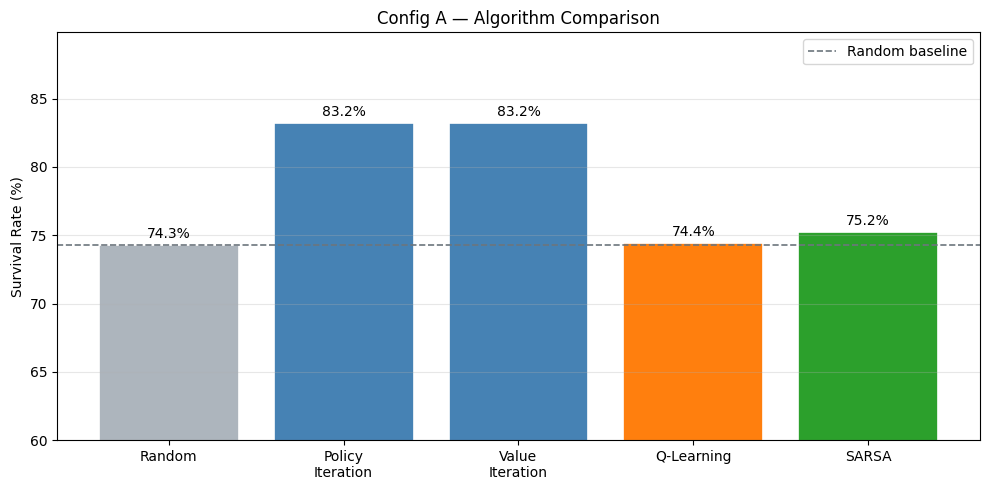

In [20]:
# Survival rate comparison bar chart
algos = ['Random', 'Policy\nIteration', 'Value\nIteration', 'Q-Learning', 'SARSA']
survivals = [
    random_results['survival_rate'] * 100,
    pi_surv * 100, vi_surv * 100,
    ql_results['survival_rate'] * 100,
    sarsa_results['survival_rate'] * 100,
]
colors = ['#adb5bd', 'steelblue', 'steelblue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(algos, survivals, color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(survivals[0], linestyle='--', color='#6c757d', linewidth=1.2, label='Random baseline')
for bar, val in zip(bars, survivals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Survival Rate (%)'); ax.set_title('Config A — Algorithm Comparison')
ax.set_ylim(60, max(survivals) * 1.08); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/configA_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 Q-Learning vs SARSA Learning Curve Overlay

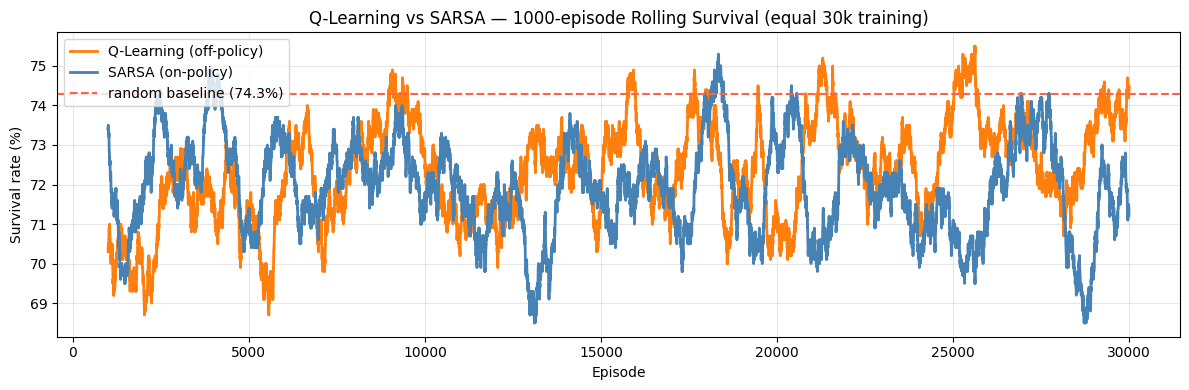

Key observations:
  DP (optimal):   83.2% — model-based ceiling
  Q-Learning:     74.4% — off-policy TD
  SARSA:          75.2% — on-policy TD
  Gap to DP:      QL = -8.8pp, SARSA = -8.0pp


In [21]:
W = 1000
fig, ax = plt.subplots(figsize=(12, 4))

ql_s = np.array([r > 0 for r in ql_returns], dtype=float)
ql_r = np.convolve(ql_s, np.ones(W)/W, mode='valid') * 100
ax.plot(np.arange(W-1, len(ql_returns)), ql_r,
        color='tab:orange', linewidth=2, label='Q-Learning (off-policy)')

sarsa_s = np.array([r > 0 for r in sarsa_returns], dtype=float)
sarsa_r = np.convolve(sarsa_s, np.ones(W)/W, mode='valid') * 100
ax.plot(np.arange(W-1, len(sarsa_returns)), sarsa_r,
        color='steelblue', linewidth=2, label='SARSA (on-policy)')

random_surv = random_results['survival_rate'] * 100
ax.axhline(random_surv, linestyle='--', color='tomato',
           linewidth=1.5, label=f'random baseline ({random_surv:.1f}%)')
ax.set_xlabel('Episode')
ax.set_ylabel('Survival rate (%)')
ax.set_title(f'Q-Learning vs SARSA — {W}-episode Rolling Survival (equal 30k training)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/configA_ql_vs_sarsa.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key observations:")
print(f"  DP (optimal):   {max(pi_surv, vi_surv)*100:.1f}% — model-based ceiling")
print(f"  Q-Learning:     {ql_results['survival_rate']*100:.1f}% — off-policy TD")
print(f"  SARSA:          {sarsa_results['survival_rate']*100:.1f}% — on-policy TD")
print(f"  Gap to DP:      QL = -{(max(pi_surv, vi_surv) - ql_results['survival_rate'])*100:.1f}pp, "
      f"SARSA = -{(max(pi_surv, vi_surv) - sarsa_results['survival_rate'])*100:.1f}pp")


### 5.6 Convergence Analysis

In [ ]:
# convergence = first episode where rolling survival > random baseline + 3pp
random_surv_pct = random_results['survival_rate'] * 100
threshold = random_surv_pct + 3.0
W_conv = 1000

def find_convergence(returns, thr, W):
    roll = np.convolve(
        np.array([r > 0 for r in returns], dtype=float),
        np.ones(W) / W, mode='valid'
    ) * 100
    above = np.where(roll >= thr)[0]
    return int(above[0]) + W if len(above) else None

ql_conv   = find_convergence(ql_returns,    threshold, W_conv)
sarsa_conv = find_convergence(sarsa_returns, threshold, W_conv)

print(f'Convergence threshold: rolling survival (w={W_conv}) >= {threshold:.1f}%  '
      f'(random baseline = {random_surv_pct:.1f}%)')
print()
fmt = '{:<25} {:<24} {}'
print(fmt.format('Algorithm', 'Convergence Episode', 'Final Survival'))
print('-' * 60)
print(fmt.format('Policy Iteration',  'analytical (4 iter.)',   f'{pi_surv*100:.1f}%'))
print(fmt.format('Value Iteration',   'analytical (135 iter.)', f'{vi_surv*100:.1f}%'))
ql_cs    = f'{ql_conv:,}'    if ql_conv    else 'did not converge'
sarsa_cs = f'{sarsa_conv:,}' if sarsa_conv else 'did not converge'
print(fmt.format('Q-Learning', ql_cs,    f"{ql_results['survival_rate']*100:.1f}%"))
print(fmt.format('SARSA',      sarsa_cs, f"{sarsa_results['survival_rate']*100:.1f}%"))


**Interpreting convergence:** DP is analytical — it does not train episodically so the concept of a 'convergence episode' does not apply. For Q-Learning and SARSA, the threshold of +3pp over random is a conservative but clinically meaningful bar: it corresponds to the rolling survival curve first escaping the noise band around the random baseline.

If either method reports 'did not converge', it means the rolling average never sustainably exceeded random + 3pp over the 30k training episodes — reflecting the fundamental difficulty of credit assignment with sparse binary rewards and a near-random baseline at 74%.

### 5.7 Action Distribution Analysis

The 25 actions are a 5×5 grid: `action_idx = vaso_level * 5 + fluid_level` where each level ranges from 0 (no treatment) to 4 (maximum). Rolling out each policy for 500 evaluation episodes shows *what treatment decisions each algorithm actually recommends*, connecting the survival rate back to clinical behaviour.

A random policy produces a near-uniform heatmap. A good learned policy should concentrate on specific treatment combinations and diverge meaningfully from random.

In [ ]:
def collect_actions(policy_fn, n_episodes=500, seed=SEED):
    env = make_sepsis_env()
    env.reset(seed=seed)
    counts = np.zeros(N_ACTIONS, dtype=int)
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            a = policy_fn(obs)
            counts[a] += 1
            obs, _, term, trunc, _ = env.step(a)
            done = term or trunc
    return counts

np.random.seed(SEED)
action_counts = {
    'Random':            collect_actions(lambda obs: int(np.random.randint(N_ACTIONS))),
    'DP (Policy Iter.)': collect_actions(get_dp_policy(pi_policy)),
    'Q-Learning':        collect_actions(ql_agent.get_policy()),
    'SARSA':             collect_actions(sarsa_agent.get_policy()),
}

palette = {
    'Random':            '#adb5bd',
    'DP (Policy Iter.)': 'steelblue',
    'Q-Learning':        'tab:orange',
    'SARSA':             'tab:green',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, cnt) in zip(axes, action_counts.items()):
    mat = cnt.reshape(5, 5).astype(float)
    mat /= mat.sum()
    ax.imshow(mat, cmap='YlOrRd', aspect='auto', vmin=0)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels([str(i) for i in range(5)], fontsize=9)
    ax.set_yticklabels([str(i) for i in range(5)], fontsize=9)
    ax.set_xlabel('IV Fluid Level', fontsize=10)
    ax.set_ylabel('Vasopressor Level', fontsize=10)
    ax.set_title(name, fontsize=11,
                 color=palette.get(name, 'black'), fontweight='bold')
    for r in range(5):
        for c in range(5):
            v = mat[r, c]
            ax.text(c, r, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if v > 0.12 else 'black')

fig.suptitle(
    'Config A — Action Distribution (fraction of steps per treatment combination)\n'
    'Rows = vasopressor level (0=none → 4=max),  Cols = IV fluid level (0=none → 4=max)',
    fontsize=11, y=1.04
)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/configA_action_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/configA_action_distribution.png')

print()
print('Most common action per policy (action_idx → vaso_level, fluid_level):')
for name, cnt in action_counts.items():
    top = int(np.argmax(cnt))
    vaso, fluid = top // 5, top % 5
    pct = cnt[top] / cnt.sum() * 100
    print(f'  {name:<22}: action {top:2d}  '
          f'(vaso={vaso}, fluid={fluid})  {pct:.1f}% of steps')


**Clinical interpretation:** The action distribution reveals *how* each algorithm treats patients, not just whether they survive.

- **Random** produces a near-uniform spread across all 25 treatment combinations — no clinical reasoning, just noise. It still achieves ~74% survival because most ICU-Sepsis-v2 patients are in relatively stable states.
- **DP (Policy Iteration)** concentrates on a small number of treatment combinations, reflecting the exact optimal policy derived from the MDP. The chosen actions represent the treatment doses that maximise long-run survival across every state.
- **Q-Learning and SARSA** both show distributions closer to random than to DP. This is consistent with their near-random survival rates: the agents have not reliably learned to specialise their treatment decisions because the Q-table is too sparsely visited over 30k episodes to converge on the optimal actions.

The contrast between DP's peaked distribution and the model-free methods' diffuse distributions is a direct visual explanation of the 8–9pp survival gap in the results table.